# Spark: pierwszy kontakt


In [ ]:
# !apt-get install openjdk-8-jdk-headless -qq > /dev/null
# !wget -q http://archive.apache.org/dist/spark/spark-3.5.1/spark-3.5.1-bin-hadoop3.tgz

In [ ]:
# !tar xf spark-3.5.1-bin-hadoop3.tgz
# !pip install -q findspark

In [ ]:
# !ls

sample_data  spark-3.5.1-bin-hadoop3  spark-3.5.1-bin-hadoop3.tgz


In [ ]:
# import os
# os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
# os.environ["SPARK_HOME"] = "/content/spark-3.5.1-bin-hadoop3"

In [ ]:
# import findspark
# findspark.init()

In [ ]:
from pyspark.sql import SparkSession
import random
import numpy as np

# Przykład

In [ ]:
# spark = SparkSession.builder.master("local[*]").getOrCreate()
# spark.conf.set("spark.sql.repl.eagerEval.enabled", True)
spark = SparkSession.builder.getOrCreate()
sc = spark.sparkContext

def inside(p):
    x, y = random.random(), random.random()
    return x*x + y*y < 1

NUM_SAMPLES = 10000000

count = sc.parallelize(range(0, NUM_SAMPLES)).filter(inside).count()
print("Pi is roughly %f" % (4.0 * count / NUM_SAMPLES))

spark.stop()


Pi is roughly 3.141748


# Zadanie 1 – całkowanie Monte Carlo
Korzystając z API RDD napisz krótki skrypt, który policzy całkę oznaczoną z $x^2 +1$ w zakresie od 0 do 2
korzystając z metody Monte Carlo (czyli w praktyce wylosuje dużo punktów w pewnym prostokącie,
sprawdzi ile z nich znalazło się pod wykresem funkcji, oraz przemnoży ten ułamek przez pole
prostokąta). Porównaj uzyskany wynik z rozwiązaniem analitycznym (jeżeli nie pamiętamy jak się
całkowało – to można je dostać np. na WolframAlpha…). Można inspirować się podobnym
przykładem dla obliczania liczby pi (https://spark.apache.org/examples.html ).

# Zadanie 2 – statystyka porównawcza tekstów
Wraz z instrukcją dostarczono również spore pliki tekstowe, zawierające dwa dzieła literackie które
na zawsze zmieniły oblicze Europy. Porównaj statystykę występujących w nich charakterystycznych
słów. Dla każdej z ksiąg wypisz 20 najczęściej występujących w niej słów, spośród tych, których
częstotliwość występowania w danym dziele jest przynajmniej 5 razy większa niż w drugim z nich
(bierzemy pod uwagę tylko słowa występujące w obu księgach).
Konieczne będzie wczytanie tekstów z plików, ich podział na słowa, sprowadzenie wszystkich do
lowercase, wyczyszczenie (usunięcie cyfr czy znaków przestankowych), policzenie częstotliwości
wystąpień, odfiltrowanie tych spełniających zadany warunek, a na koniec wypisanie wyniku.
Korzystamy z API RDD.


# Zadanie 3 – wizualizacja rozkładu słów w tekstach
Na koniec prześledzimy rozkład chmury słów w obu dokumentach, korzystając z API DataFrame i
gotowych rozwiązań z MLlib. Zrobimy to w następujący sposób:
* wczytamy oba teksty dzieląc je po kropkach na zdania
* scalimy je następnie do jednego DF
* użyjemy RegexTokenizera by podzielić zdania na słowa
* użyjemy StopWordsRemovera by usunąć słowa nieistotne semantycznie
* użyjemy algorytmu Word2Vec by każdemu ze słów przypisać (na podstawie kontekstu w
którym występowało) dwuwymiarowy wektor je reprezentujący
* wyniki zapiszemy do pliku w postaci trzech kolumn (z której książki pochodziło słowo –
wartość pierwszej współrzędnej wektora – wartość drugiej współrzędnej wektora)
* zwizualizujemy dowolnym narzędziem pozwalającym na rysowanie scatter plots
* efekt powinien być podobny jak poniżej




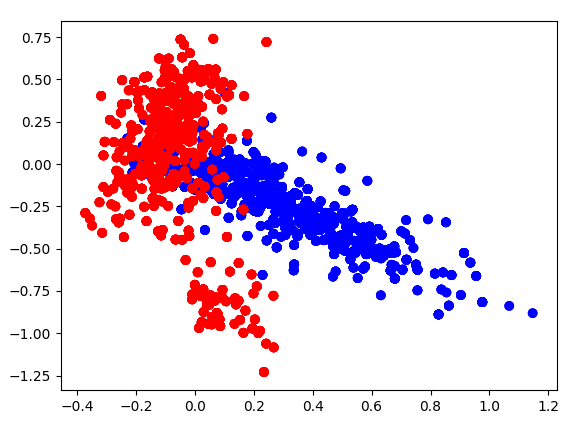

# Nie wiem jak mam coś zrobić – jak żyć?
Prowadzący powinien rozpocząć zajęcia od krótkiego wstępu. Będzie on pobieżnym streszczenie oficjalnych materiałów szkoleniowych od Apache. W szczególności zaś:
* https://spark.apache.org/docs/latest/quick-start.html (szybki start ze Sparkiem)
* https://spark.apache.org/docs/latest/rdd-programming-guide.html (wprowadzenie do RDD)
* https://spark.apache.org/docs/latest/sql-programming-guide.html (wprowadzenie do DataFrames)
* https://spark.apache.org/docs/latest/ml-guide.html (wprowadzenie do MLliba)
* oraz najważniejszego, czyli dokumentacji samego API - https://spark.apache.org/docs/latest/api/python/pyspark.html

P.S. Nie martw się, jeżeli nie zdążysz zrobić wszystkich zadań – zostały przygotowane „na zapas”, na wypadek gdyby ich rozwiązywanie szło bardzo szybko.